## Testing ground for 42 DSLR project 

In [2]:
import pandas as pd

train_data: pd.DataFrame = pd.read_csv('../datasets/dataset_train.csv')
train_data.head(10)

,Index,Hogwarts House,First Name,Last Name,Birthday,Best Hand,Arithmancy,Astronomy,Herbology,Defense Against the Dark Arts,Divination,Muggle Studies,Ancient Runes,History of Magic,Transfiguration,Potions,Care of Magical Creatures,Charms,Flying
0,0,Ravenclaw,Tamara,Hsu,2000-03-30,Left,58384.0,-487.886086,5.727180,4.878861,4.722,272.035831,532.484226,5.231058,1039.788281,3.790369,0.715939,-232.79405,-26.89
1,1,Slytherin,Erich,Paredes,1999-10-14,Right,67239.0,-552.060507,-5.987446,5.520605,-5.612,-487.340557,367.760303,4.107170,1058.944592,7.248742,0.091674,-252.18425,-113.45
2,2,Ravenclaw,Stephany,Braun,1999-11-03,Left,23702.0,-366.076117,7.725017,3.660761,6.140,664.893521,602.585284,3.555579,1088.088348,8.728531,-0.515327,-227.34265,30.42
3,3,Gryffindor,Vesta,Mcmichael,2000-08-19,Left,32667.0,697.742809,-6.497214,-6.977428,4.026,-537.001128,523.982133,-4.809637,920.391449,0.821911,-0.014040,-256.84675,200.64
4,4,Gryffindor,Gaston,Gibbs,1998-09-27,Left,60158.0,436.775204,-7.820623,NaN,2.236,-444.262537,599.324514,-3.444377,937.434724,4.311066,-0.264070,-256.38730,157.98
5,5,Slytherin,Corrine,Hammond,1999-04-04,Right,21209.0,-613.687160,-4.289197,6.136872,-6.592,-440.997704,396.201804,5.380286,1052.845164,11.751212,1.049894,-247.94549,-34.69
6,6,Gryffindor,Tom,Guido,2000-09-30,Left,49167.0,628.046051,-4.861976,-6.280461,NaN,-926.892512,583.742442,-7.322486,923.539573,1.646666,0.153022,-257.83447,261.55
7,7,Hufflepuff,Alicia,Hayward,1997-07-08,Right,33010.0,411.412727,5.931832,-4.114127,2.769,-502.021336,439.351416,NaN,1041.091935,6.581791,-0.171704,-244.03492,72.25
8,8,Gryffindor,Bella,Leatherman,1998-12-07,Left,20278.0,496.394945,-5.215891,-4.963949,5.855,-626.552041,567.842402,-6.198661,925.255500,1.086518,1.147032,-252.27561,244.11
9,9,Hufflepuff,Hayden,Aponte,2001-10-13,Right,46316.0,527.193585,7.922205,-5.271936,3.356,-398.101991,341.475606,4.978614,1041.414665,2.068824,-0.529579,-244.57527,-0.09


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Index                          1600 non-null   int64  
 1   Hogwarts House                 1600 non-null   object 
 2   First Name                     1600 non-null   object 
 3   Last Name                      1600 non-null   object 
 4   Birthday                       1600 non-null   object 
 5   Best Hand                      1600 non-null   object 
 6   Arithmancy                     1566 non-null   float64
 7   Astronomy                      1568 non-null   float64
 8   Herbology                      1567 non-null   float64
 9   Defense Against the Dark Arts  1569 non-null   float64
 10  Divination                     1561 non-null   float64
 11  Muggle Studies                 1565 non-null   float64
 12  Ancient Runes                  1565 non-null   f

## V.2 Data Visualization


### V.2.1 Histogram
Create a script called histogram.[extension] which displays a histogram answering the
following question:
Which Hogwarts course has a homogeneous score distribution between all four houses?

### V.2.1 Solution Strategy
We compare score distributions per course across Hogwarts houses.

Homogeneity score used:
- Compute each house mean for a course
- Compute the standard deviation of those four means
- Lower value => more homogeneous across houses

Then we plot overlapping histograms for the best candidate course.

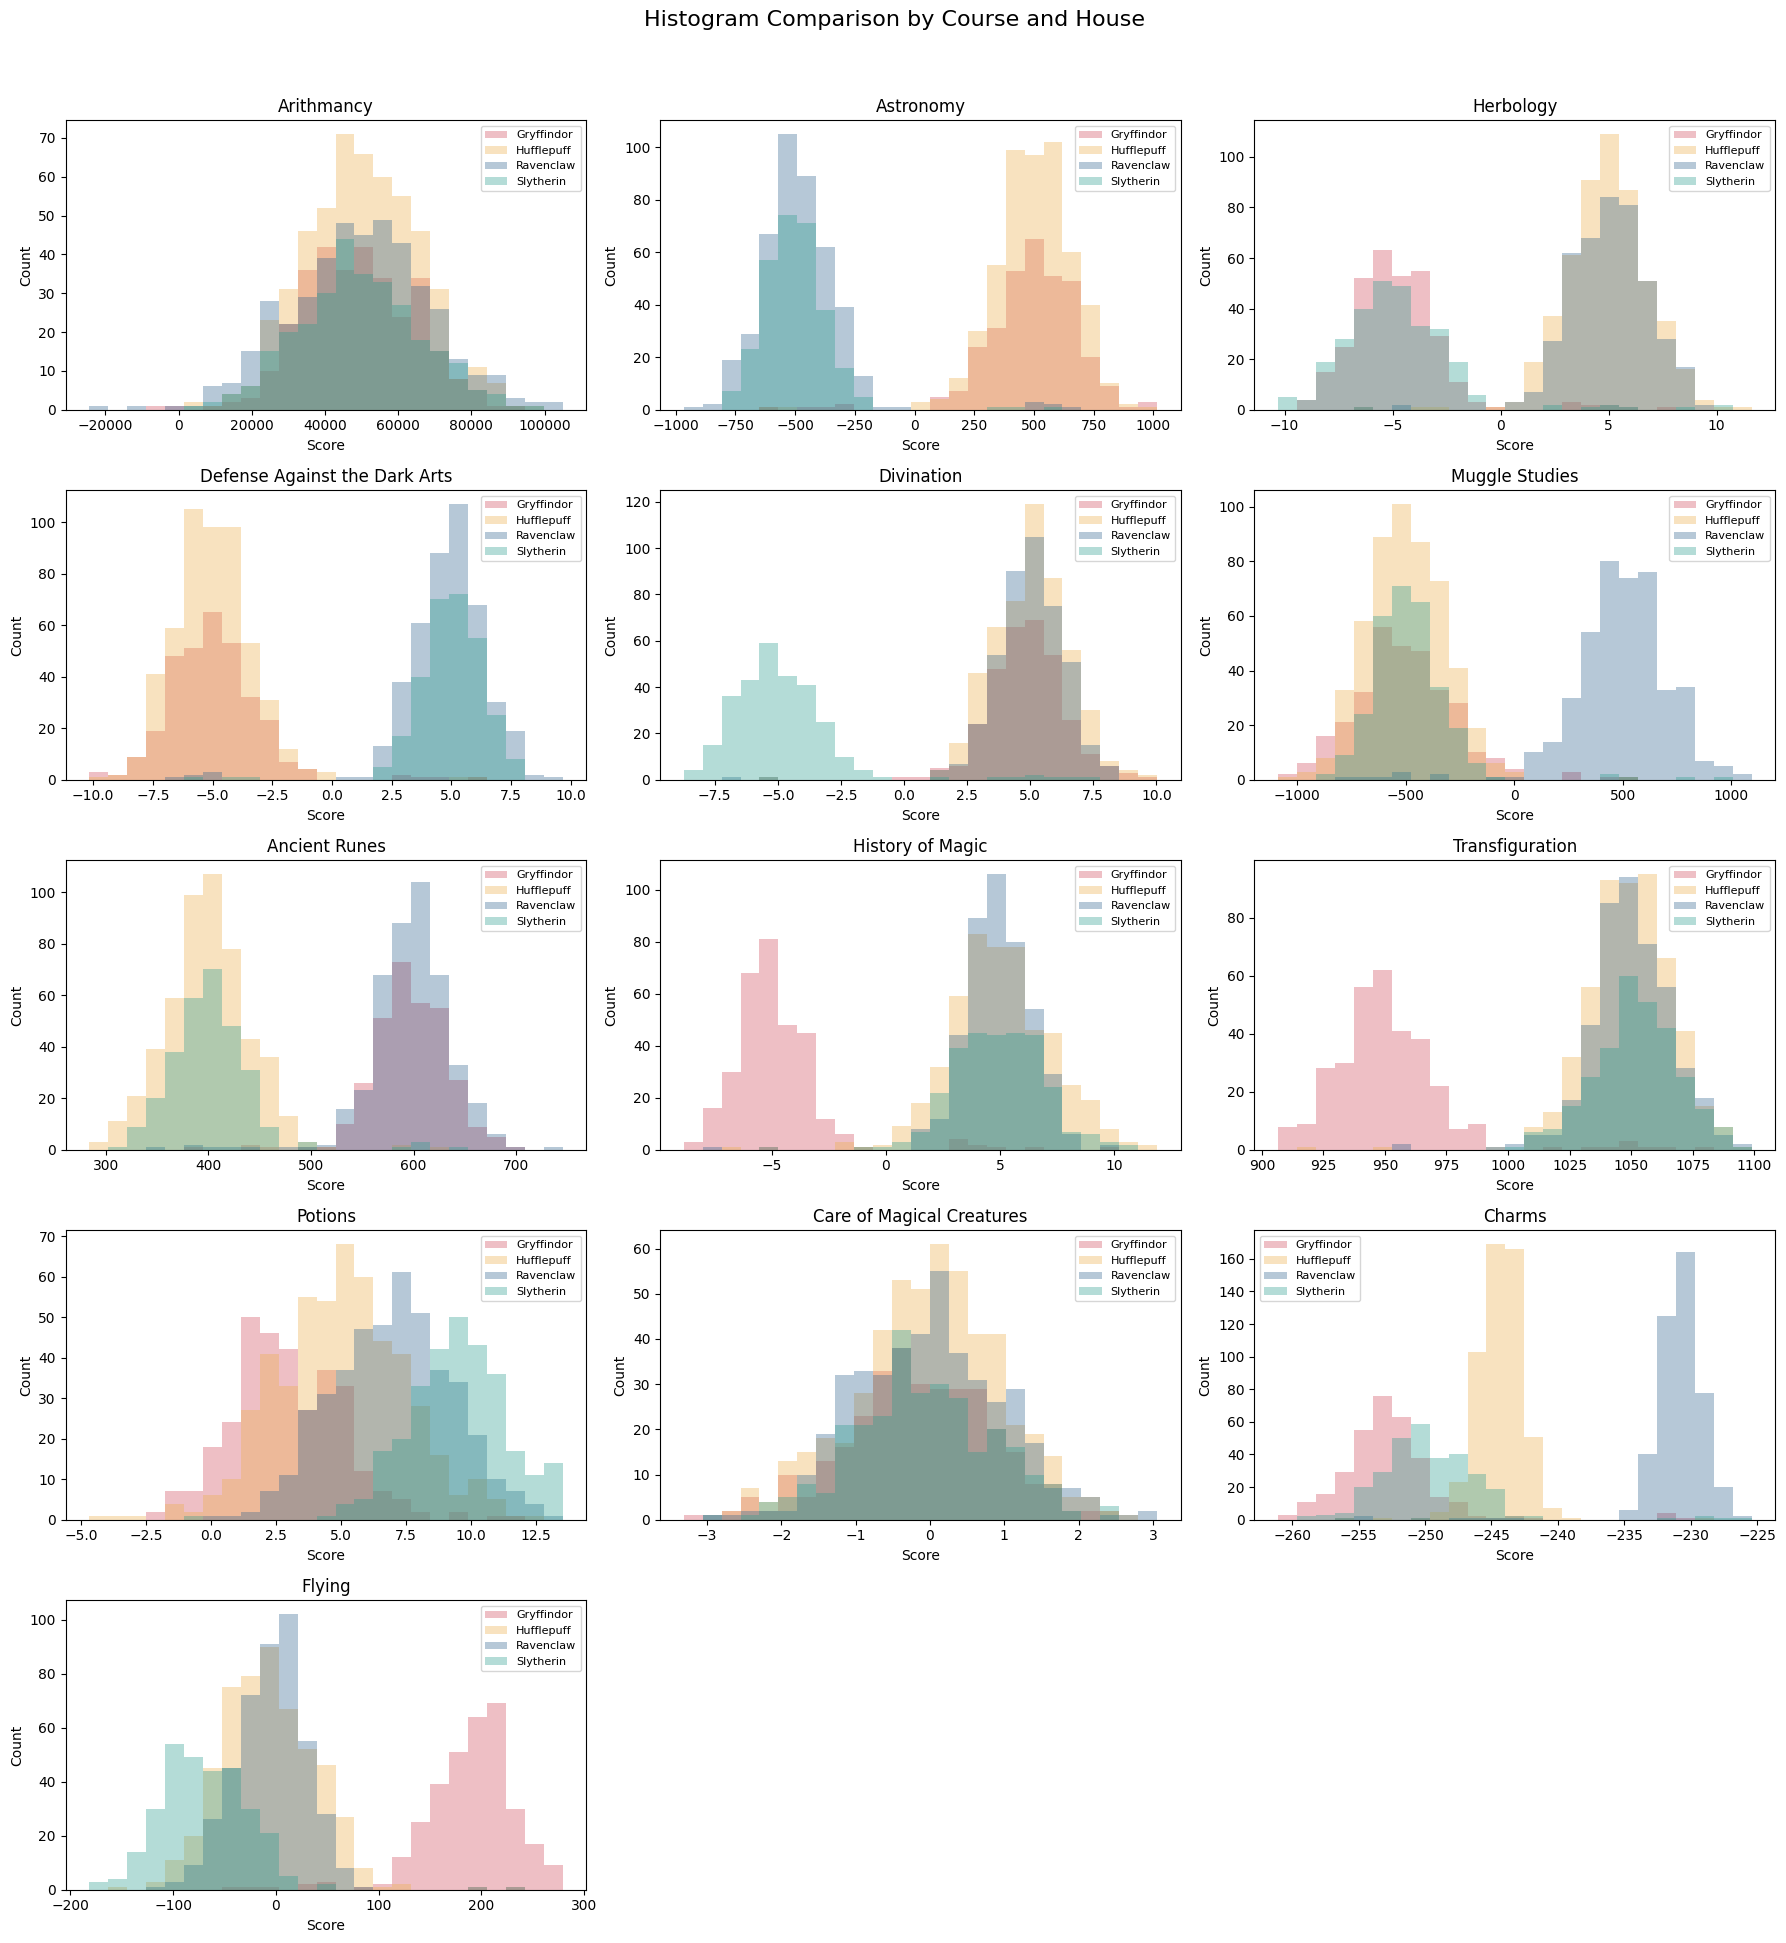

In [9]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = train_data.copy()
house_col = 'Hogwarts House'

# Keep only numeric course columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
course_cols = [c for c in numeric_cols if c != 'Index']

houses = sorted(df[house_col].dropna().unique().tolist())
colors = {
    'Gryffindor': '#d1495b',
    'Hufflepuff': '#edae49',
    'Ravenclaw': '#30638e',
    'Slytherin': '#2a9d8f',
}

# def overlap_score_for_course(dataframe: pd.DataFrame, course: str, bins: int = 25) -> float:
#     # Use shared bin edges across all houses for fair shape comparison
#     all_values = dataframe[course].dropna()
#     if all_values.empty:
#         return 0.0

#     bin_edges = np.histogram_bin_edges(all_values, bins=bins)
#     densities = []
#     valid_houses = 0

#     for house in houses:
#         values = dataframe.loc[dataframe[house_col] == house, course].dropna()
#         if values.empty:
#             continue
#         hist, _ = np.histogram(values, bins=bin_edges, density=True)
#         densities.append(hist)
#         valid_houses += 1

#     if valid_houses < 2:
#         return 0.0

#     # Mean pairwise histogram intersection in [0, 1]
#     intersections = []
#     for i in range(len(densities)):
#         for j in range(i + 1, len(densities)):
#             intersection = np.minimum(densities[i], densities[j]).sum()
#             union = np.maximum(densities[i], densities[j]).sum()
#             intersections.append(intersection / union if union > 0 else 0.0)

#     return float(np.mean(intersections)) if intersections else 0.0

# scores = []
# for course in course_cols:
#     score = overlap_score_for_course(df, course)
#     scores.append({'Course': course, 'OverlapScore': score})

# homogeneity_df = pd.DataFrame(scores).sort_values('OverlapScore', ascending=False).reset_index(drop=True)
# best_course = homogeneity_df.loc[0, 'Course']

# print('Most homogeneous course candidate:', best_course)
# print('\nTop 5 by overlap score (higher is better):')
# display(homogeneity_df.head(5))

# Plot all courses with 4 overlapping histograms each
n_courses = len(course_cols)
n_cols = 3
n_rows = math.ceil(n_courses / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.8 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, course in enumerate(course_cols):
    ax = axes[idx]
    all_values = df[course].dropna()
    if all_values.empty:
        ax.set_title(f'{course} (no data)')
        ax.axis('off')
        continue

    shared_bins = np.histogram_bin_edges(all_values, bins=25)

    for house in houses:
        values = df.loc[df[house_col] == house, course].dropna()
        if values.empty:
            continue
        ax.hist(
            values,
            bins=shared_bins,
            alpha=0.35,
            label=house,
            color=colors.get(house),
            edgecolor='none'
        )

    # mark = ' <- best overlap' if course == best_course else ''
    ax.set_title(f'{course}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for idx in range(n_courses, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Histogram Comparison by Course and House', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

Top 12 most similar feature pairs (by absolute correlation):


,Feature A,Feature B,Correlation,AbsCorrelation,Samples
0,Astronomy,Defense Against the Dark Arts,-1.000000,1.000000,1537
1,History of Magic,Flying,-0.896283,0.896283,1557
2,Transfiguration,Flying,-0.873673,0.873673,1566
3,History of Magic,Transfiguration,0.849203,0.849203,1523
4,Muggle Studies,Charms,0.847607,0.847607,1565
5,Herbology,Charms,0.746614,0.746614,1567
6,History of Magic,Potions,0.602211,0.602211,1529
7,Astronomy,Muggle Studies,-0.578511,0.578511,1533
8,Defense Against the Dark Arts,Muggle Studies,0.576553,0.576553,1534
9,Muggle Studies,Ancient Runes,0.569814,0.569814,1530



Best match for each feature:


,Feature,Most Similar To,Correlation,AbsCorrelation,Samples
0,Astronomy,Defense Against the Dark Arts,-1.000000,1.000000,1537
1,Defense Against the Dark Arts,Astronomy,-1.000000,1.000000,1537
2,History of Magic,Flying,-0.896283,0.896283,1557
3,Flying,History of Magic,-0.896283,0.896283,1557
4,Transfiguration,Flying,-0.873673,0.873673,1566
5,Muggle Studies,Charms,0.847607,0.847607,1565
6,Charms,Muggle Studies,0.847607,0.847607,1565
7,Herbology,Charms,0.746614,0.746614,1567
8,Potions,History of Magic,0.602211,0.602211,1529
9,Ancient Runes,Muggle Studies,0.569814,0.569814,1530


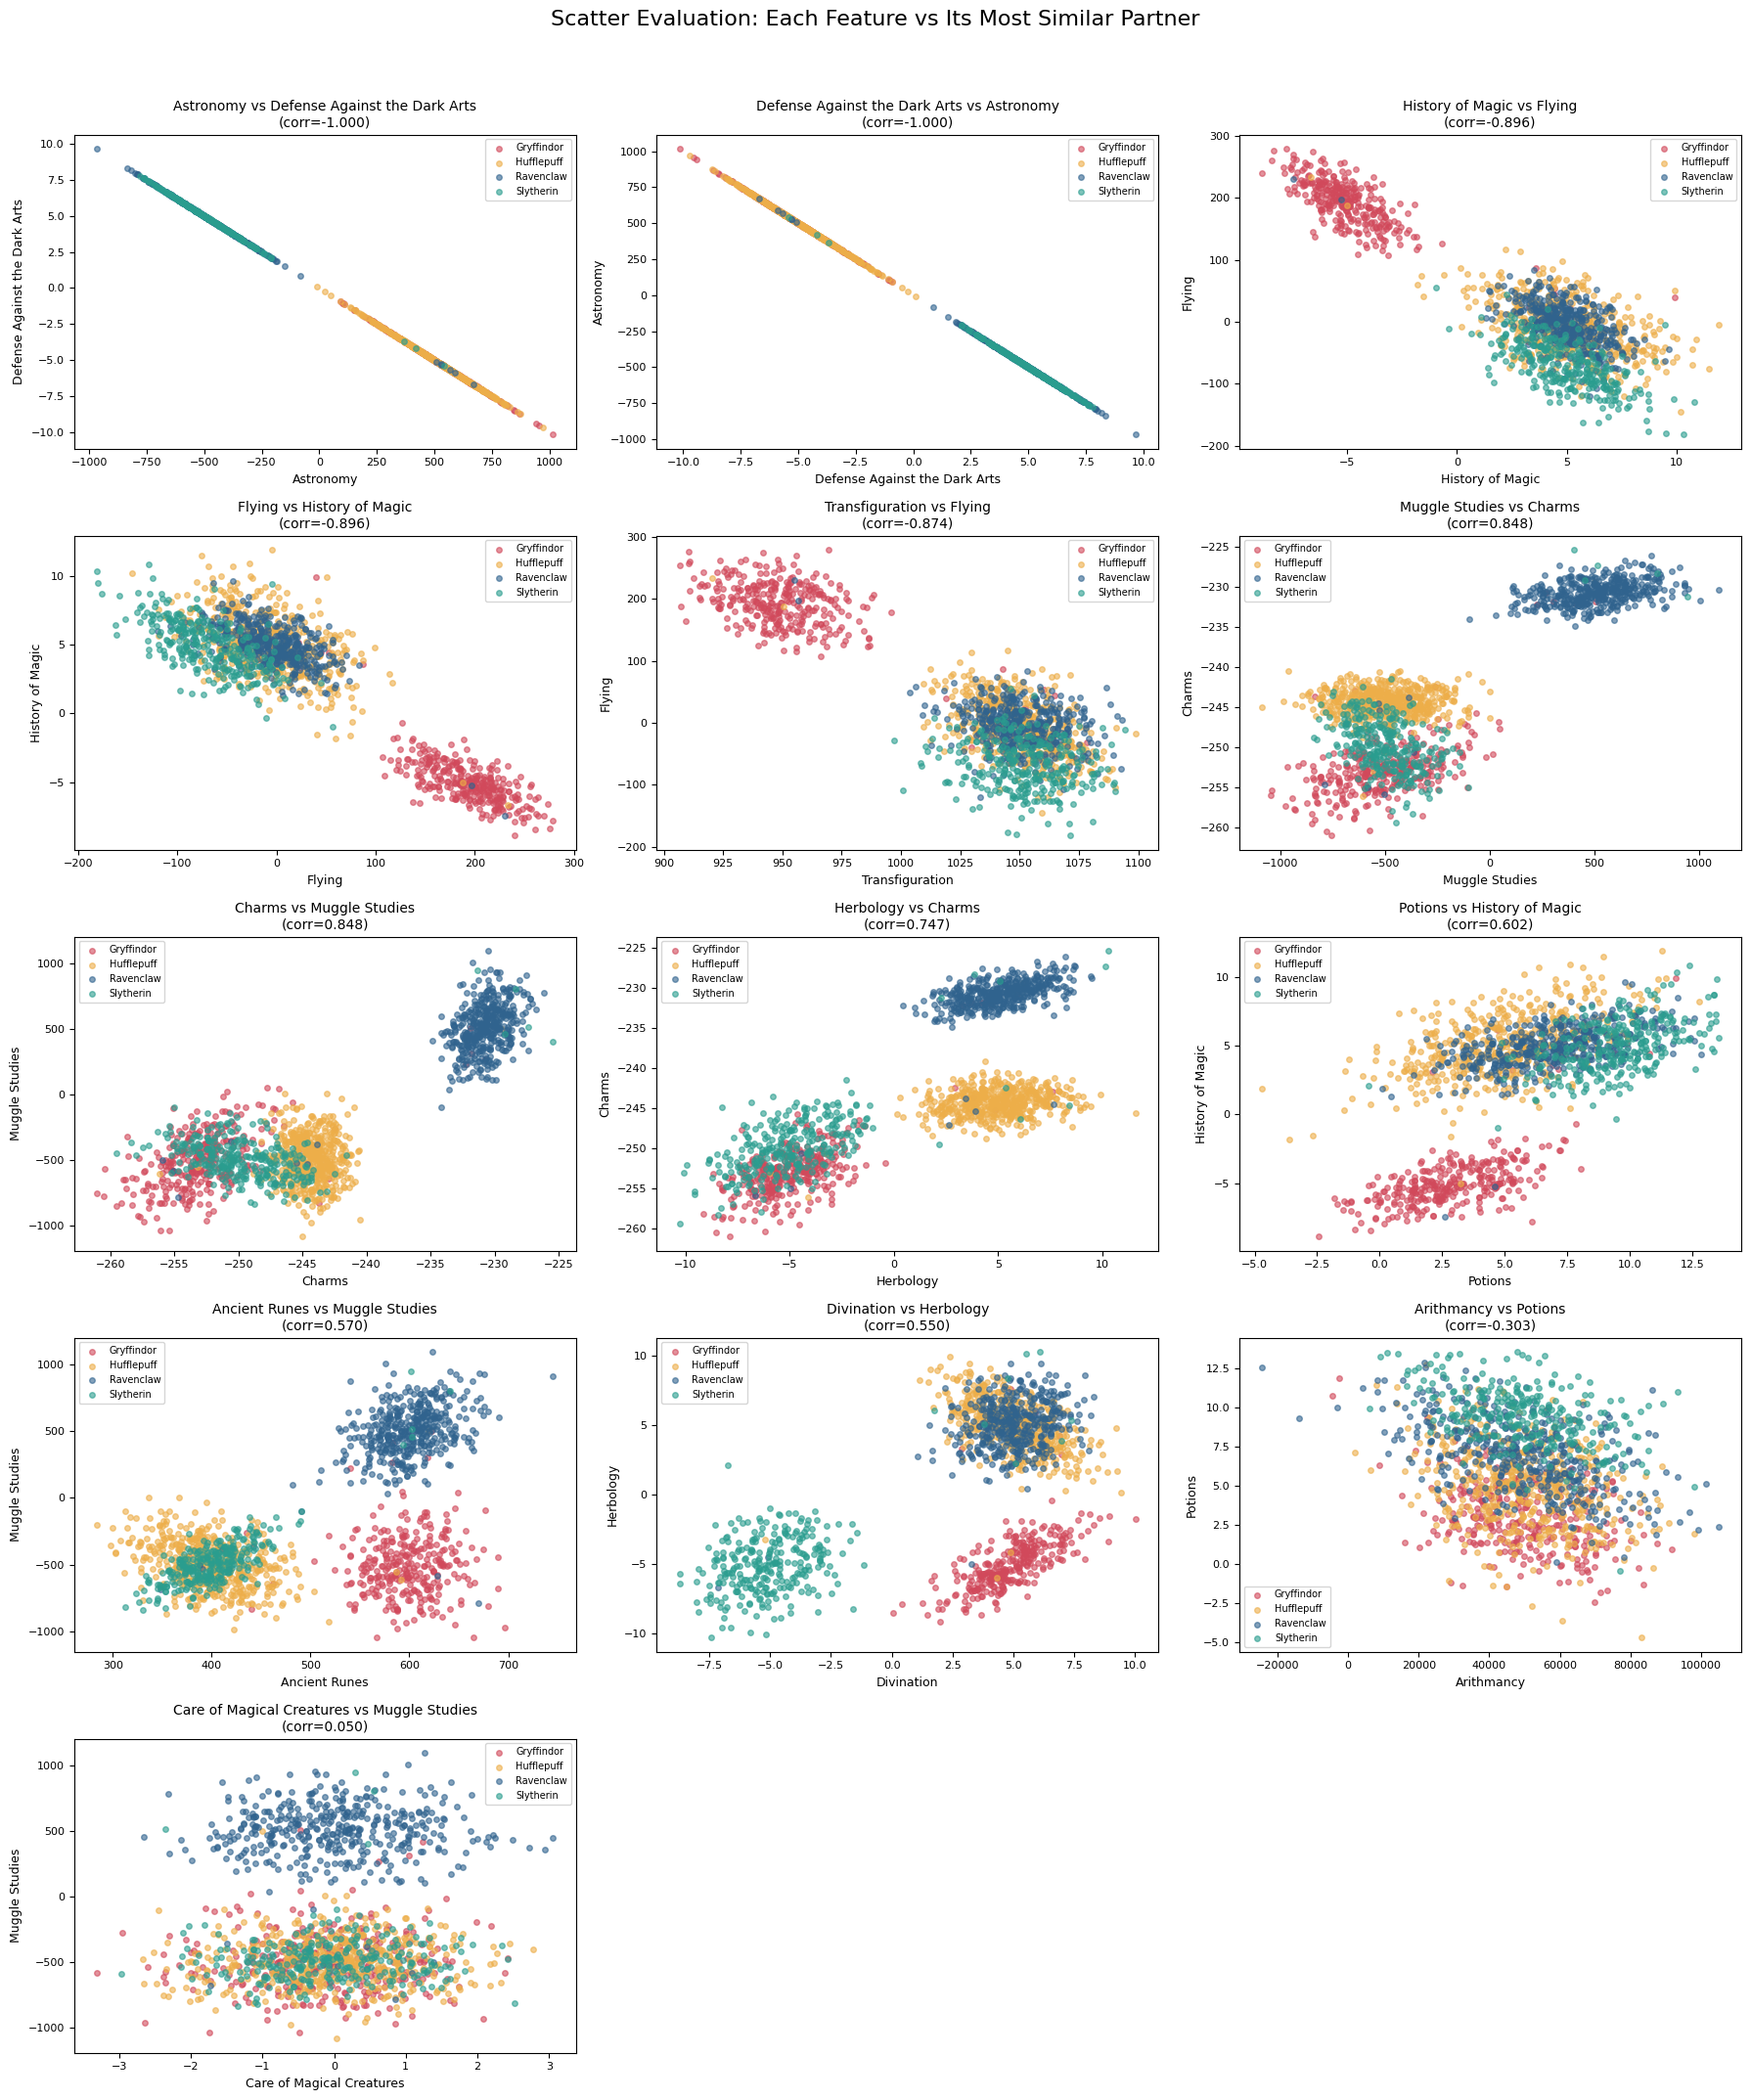

In [11]:
from itertools import combinations
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_scatter = train_data.copy()
house_col = 'Hogwarts House'

# Select numeric feature columns
numeric_cols = df_scatter.select_dtypes(include=['number']).columns.tolist()
feature_cols = [col for col in numeric_cols if col != 'Index']

# 1) Evaluate ALL feature pairs with correlation
pair_scores = []
for left, right in combinations(feature_cols, 2):
    pair_data = df_scatter[[left, right]].dropna()
    if pair_data.empty:
        continue
    corr = pair_data[left].corr(pair_data[right])
    if pd.isna(corr):
        continue
    pair_scores.append({
        'Feature A': left,
        'Feature B': right,
        'Correlation': float(corr),
        'AbsCorrelation': abs(float(corr)),
        'Samples': len(pair_data),
    })

pair_scores_df = pd.DataFrame(pair_scores).sort_values('AbsCorrelation', ascending=False).reset_index(drop=True)

if pair_scores_df.empty:
    raise ValueError('No valid feature pairs found for scatter evaluation.')

print('Top 12 most similar feature pairs (by absolute correlation):')
display(pair_scores_df.head(12))

# 2) Evaluate EACH feature by finding its single most similar partner
best_by_feature = []
for feature in feature_cols:
    feature_pairs = pair_scores_df[
        (pair_scores_df['Feature A'] == feature) | (pair_scores_df['Feature B'] == feature)
    ]
    if feature_pairs.empty:
        continue

    best_row = feature_pairs.iloc[0]
    other = best_row['Feature B'] if best_row['Feature A'] == feature else best_row['Feature A']
    best_by_feature.append({
        'Feature': feature,
        'Most Similar To': other,
        'Correlation': best_row['Correlation'],
        'AbsCorrelation': best_row['AbsCorrelation'],
        'Samples': int(best_row['Samples']),
    })

best_by_feature_df = pd.DataFrame(best_by_feature).sort_values('AbsCorrelation', ascending=False).reset_index(drop=True)

print('\nBest match for each feature:')
display(best_by_feature_df)

# 3) Scatter plots: one panel per feature vs its most similar feature
colors = {
    'Gryffindor': '#d1495b',
    'Hufflepuff': '#edae49',
    'Ravenclaw': '#30638e',
    'Slytherin': '#2a9d8f',
}

n_panels = len(best_by_feature_df)
n_cols = 3
n_rows = math.ceil(n_panels / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, row in best_by_feature_df.iterrows():
    ax = axes[idx]
    x_feature = row['Feature']
    y_feature = row['Most Similar To']
    pair_corr = row['Correlation']

    for house, group in df_scatter.groupby(house_col):
        subset = group[[x_feature, y_feature]].dropna()
        if subset.empty:
            continue
        ax.scatter(
            subset[x_feature],
            subset[y_feature],
            alpha=0.6,
            s=16,
            label=house,
            c=colors.get(house, '#666666')
        )

    ax.set_title(f"{x_feature} vs {y_feature}\n(corr={pair_corr:.3f})", fontsize=10)
    ax.set_xlabel(x_feature, fontsize=9)
    ax.set_ylabel(y_feature, fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=7, loc='best')

for idx in range(n_panels, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Scatter Evaluation: Each Feature vs Its Most Similar Partner', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()